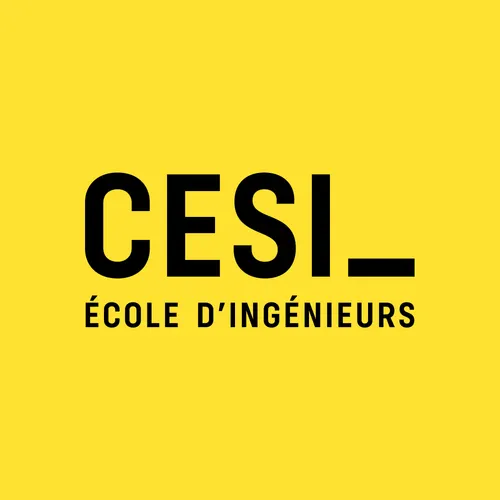

# Deliverable 1
## <center>  Diabetes prediction project


### Group 4:
- Jennifer S
- Hawiana AB
- Adnan CJ

# Context

We have been tasked to build a binary classification model to predict diabetes risk using CDC BRFSS 2015 survey data. The work follows an MLOps approach and is organized in three sprints.

During this deliverable, we'll focus on data preparation i.e the foundational phase that ensures raw data is cleaned, understood, and transformed into a format suitable for modeling.

# Objectives

The goal of this deliverable is to transform the raw dataset into a clean, well-documented, and ready-to-use state for the modeling phase. By following the below plan:


1. ***Load & Understand***	Import the dataset, examine its structure, shape, and target distribution
2. ***Clean the Data***	Remove duplicate records and handle any missing values
3. ***Separate Variables***	Distinguish target variable (Diabetes_012) from explanatory features
4. ***Verify Data Types***	Ensure all variables are correctly typed (binary, numerical, categorical)
5. ***Perform EDA***	Conduct quantitative (descriptive stats, correlations) and qualitative (visualizations) exploratory analysis
6. ***Normalize Features***	Apply standardization to numerical features for models that require scaling
7. ***Split the Data***	Divide dataset into training, validation, and test sets
8. ***Save Cleaned Data***	Export cleaned and normalized versions for use in Sprint 2

# Importing

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Loading data

In [23]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\Sprint 1\Sprint 1\diabetes_012_health_indicators_BRFSS2015.csv").sample(n=240, random_state=42)  # Load a sample of the dataset for faster processing

print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

Shape: (240, 22)

First 5 rows:
        Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
219620           0.0     0.0       0.0        1.0  21.0     0.0     0.0   
132821           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
151862           0.0     0.0       0.0        1.0  24.0     0.0     0.0   
139717           0.0     0.0       0.0        1.0  27.0     1.0     0.0   
239235           0.0     0.0       1.0        1.0  31.0     1.0     0.0   

        HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
219620                   0.0           0.0     1.0  ...            1.0   
132821                   0.0           1.0     1.0  ...            1.0   
151862                   0.0           1.0     1.0  ...            1.0   
139717                   0.0           1.0     0.0  ...            1.0   
239235                   0.0           0.0     1.0  ...            1.0   

        NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  \

# Initial understanding of data

In [24]:
print("\nColumn names and data types:")
print(df.dtypes)

print("\nDataset info:")
df.info()

print("\nTarget distribution (Diabetes_012):")
print(df['Diabetes_012'].value_counts().sort_index())


Column names and data types:
Diabetes_012            float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object

Dataset info:
<class 'pandas.core.frame.DataFrame'>
Index: 240 entries, 219620 to 239507
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_012          

In [25]:
df.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,...,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000
mean,0.191667,0.400000,0.391667,0.966667,28.779167,0.479167,0.020833,0.100000,0.750000,0.645833,...,0.966667,0.075000,2.445833,3.295833,3.745833,0.129167,0.500000,7.658333,5.020833,6.254167
std,0.568281,0.490922,0.489143,0.179881,7.025743,0.500610,0.143125,0.300627,0.433918,0.479260,...,0.179881,0.263942,1.077141,7.683051,8.158856,0.336085,0.501045,3.085927,1.003958,2.032678
min,0.000000,0.000000,0.000000,0.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,0.750000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,5.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.500000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,32.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,2.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,77.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


array([[<Axes: title={'center': 'Diabetes_012'}>,
        <Axes: title={'center': 'HighBP'}>,
        <Axes: title={'center': 'HighChol'}>,
        <Axes: title={'center': 'CholCheck'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'Smoker'}>,
        <Axes: title={'center': 'Stroke'}>,
        <Axes: title={'center': 'HeartDiseaseorAttack'}>,
        <Axes: title={'center': 'PhysActivity'}>,
        <Axes: title={'center': 'Fruits'}>],
       [<Axes: title={'center': 'Veggies'}>,
        <Axes: title={'center': 'HvyAlcoholConsump'}>,
        <Axes: title={'center': 'AnyHealthcare'}>,
        <Axes: title={'center': 'NoDocbcCost'}>,
        <Axes: title={'center': 'GenHlth'}>],
       [<Axes: title={'center': 'MentHlth'}>,
        <Axes: title={'center': 'PhysHlth'}>,
        <Axes: title={'center': 'DiffWalk'}>,
        <Axes: title={'center': 'Sex'}>, <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Education'}>,
        <Axes: title={'c

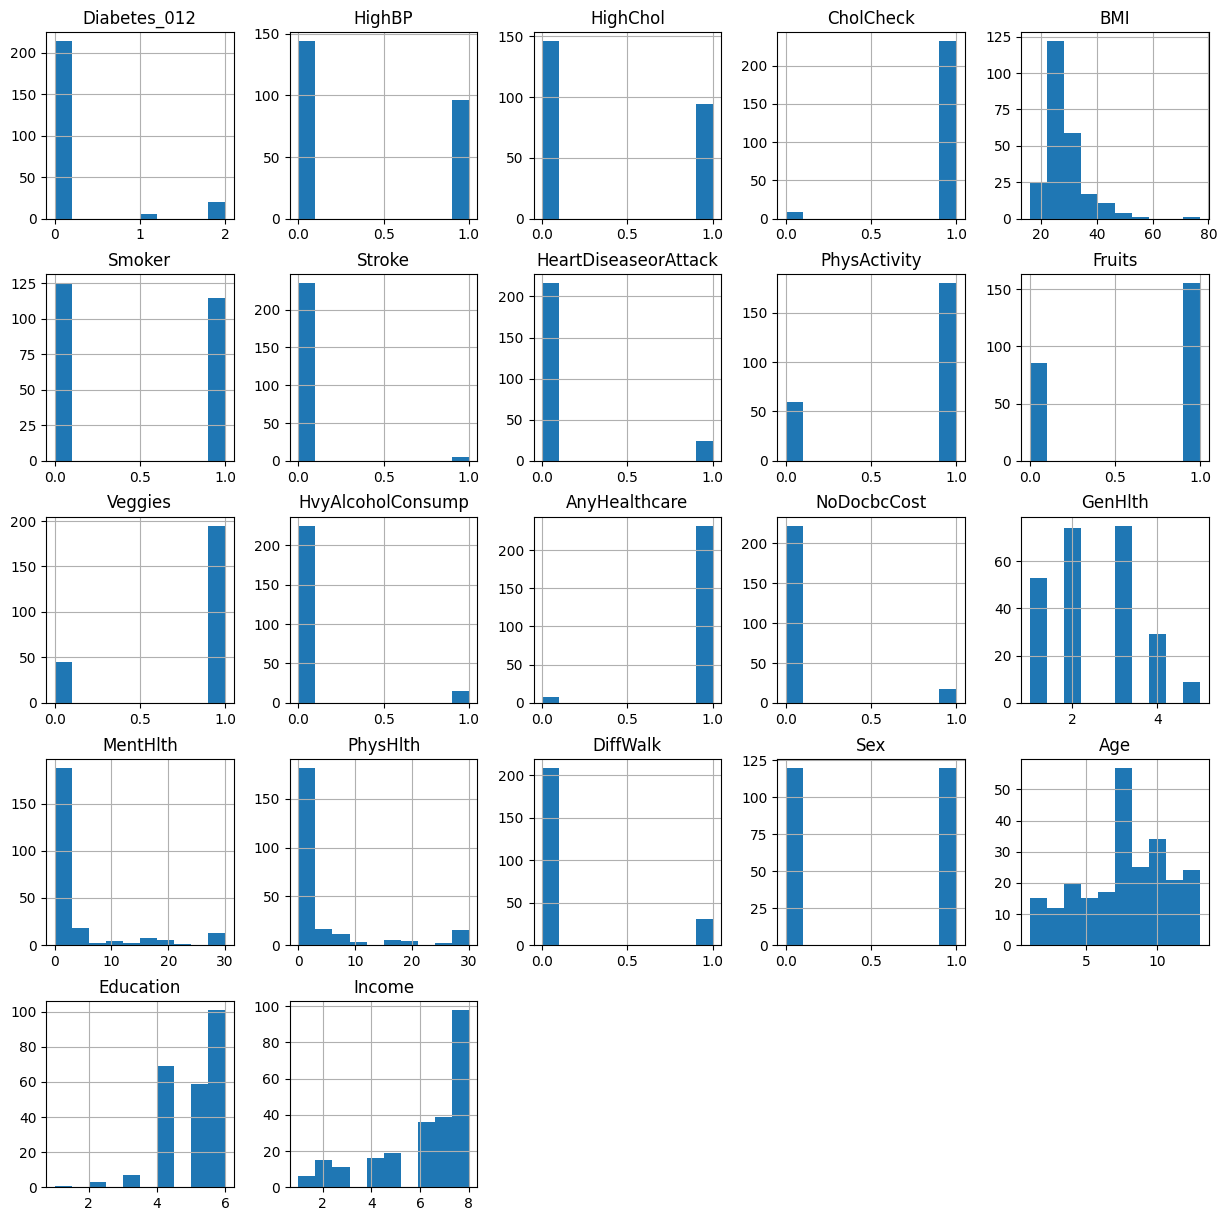

In [26]:
df.hist(figsize=(15, 15))

# Check for duplicates and cleaning of data

In [27]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count:,}")
if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")

Duplicate rows: 0


## Check missing values

In [28]:
print(f"\nMissing values per column:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("No missing values found!")


Missing values per column:
No missing values found!


## Creation of a binary target i.e classifying data

The Diabetes Binary variable transforms the original three-class target into a binary format by grouping prediabetes $1$ and no diabetes $0$ into a single positive class *0*, while keeping diabetes $1$ as the positive class *1*.

In [29]:
df['Diabetes_binary'] = (df['Diabetes_012'] == 2).astype(int)

print(f"Diabetes_binary distribution:")
print(f"  0 (No Diabetes or Prediabetes): {(df['Diabetes_binary']==0).sum():,}")
print(f"  1 (Diabetes): {(df['Diabetes_binary']==1).sum():,}")

Diabetes_binary distribution:
  0 (No Diabetes or Prediabetes): 220
  1 (Diabetes): 20


## visualisation of classes

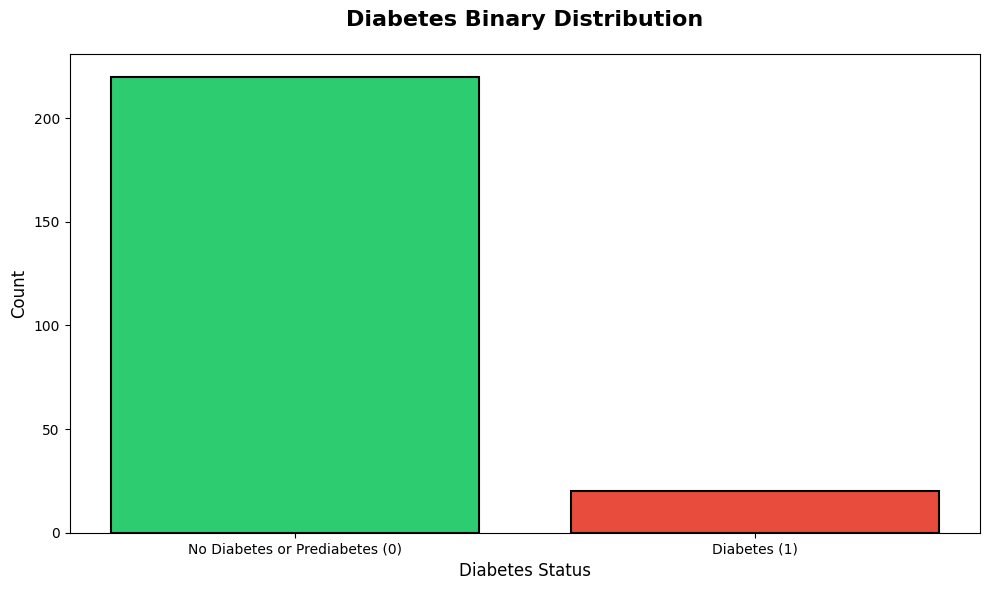

In [30]:
labels = ['No Diabetes or Prediabetes (0)', 'Diabetes (1)']
counts = [df['Diabetes_binary'].value_counts()[0], df['Diabetes_binary'].value_counts()[1]]
colors = ['#2ecc71', '#e74c3c']

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(labels, counts, color=colors, edgecolor='black', linewidth=1.5)

ax.set_title('Diabetes Binary Distribution', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Count', fontsize=12)
ax.set_xlabel('Diabetes Status', fontsize=12)


plt.tight_layout()
plt.show()

# Quantitative *Analysis*
## Descriptive statistics

In [31]:
print("\nDescriptive Statistics (Numerical Features):")
print(df.describe())


Descriptive Statistics (Numerical Features):
       Diabetes_012      HighBP    HighChol   CholCheck         BMI  \
count    240.000000  240.000000  240.000000  240.000000  240.000000   
mean       0.191667    0.400000    0.391667    0.966667   28.779167   
std        0.568281    0.490922    0.489143    0.179881    7.025743   
min        0.000000    0.000000    0.000000    0.000000   16.000000   
25%        0.000000    0.000000    0.000000    1.000000   24.000000   
50%        0.000000    0.000000    0.000000    1.000000   27.000000   
75%        0.000000    1.000000    1.000000    1.000000   32.000000   
max        2.000000    1.000000    1.000000    1.000000   77.000000   

           Smoker      Stroke  HeartDiseaseorAttack  PhysActivity      Fruits  \
count  240.000000  240.000000            240.000000    240.000000  240.000000   
mean     0.479167    0.020833              0.100000      0.750000    0.645833   
std      0.500610    0.143125              0.300627      0.433918    0.

## Correlation with the target

In [32]:
print("\nCorrelation with Diabetes_binary:")
correlations = df.corr()['Diabetes_binary'].sort_values(ascending=False)
print(correlations)



Correlation with Diabetes_binary:
Diabetes_binary         1.000000
Diabetes_012            0.961448
BMI                     0.286879
GenHlth                 0.253622
DiffWalk                0.243480
HighBP                  0.215410
HeartDiseaseorAttack    0.201008
Age                     0.175421
Stroke                  0.167124
HighChol                0.159571
PhysHlth                0.068664
CholCheck               0.055989
AnyHealthcare           0.055989
Veggies                 0.028968
NoDocbcCost             0.028618
Smoker                  0.012574
MentHlth               -0.029330
Sex                    -0.030151
PhysActivity           -0.034816
HvyAlcoholConsump      -0.077850
Fruits                 -0.091938
Education              -0.126650
Income                 -0.178990
Name: Diabetes_binary, dtype: float64


# Qualitative Analysis
## Target distribution plot

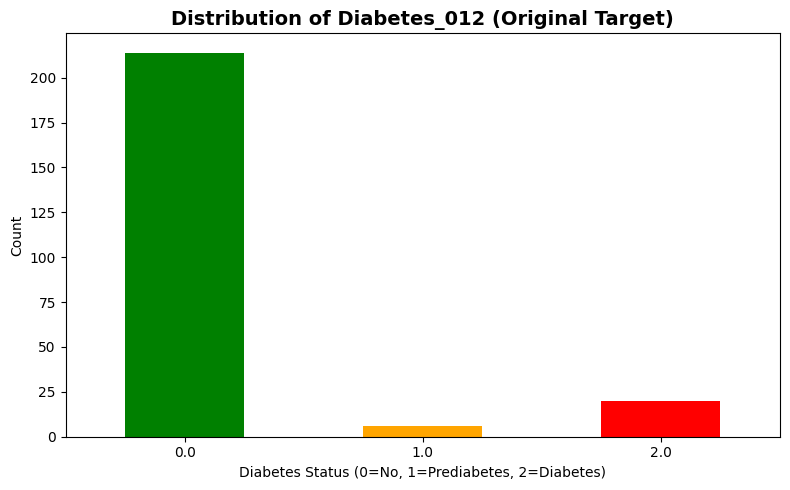

In [33]:
plt.figure(figsize=(8, 5))
df['Diabetes_012'].value_counts().sort_index().plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Distribution of Diabetes_012 (Original Target)', fontsize=14, fontweight='bold')
plt.xlabel('Diabetes Status (0=No, 1=Prediabetes, 2=Diabetes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Correlation heatmap

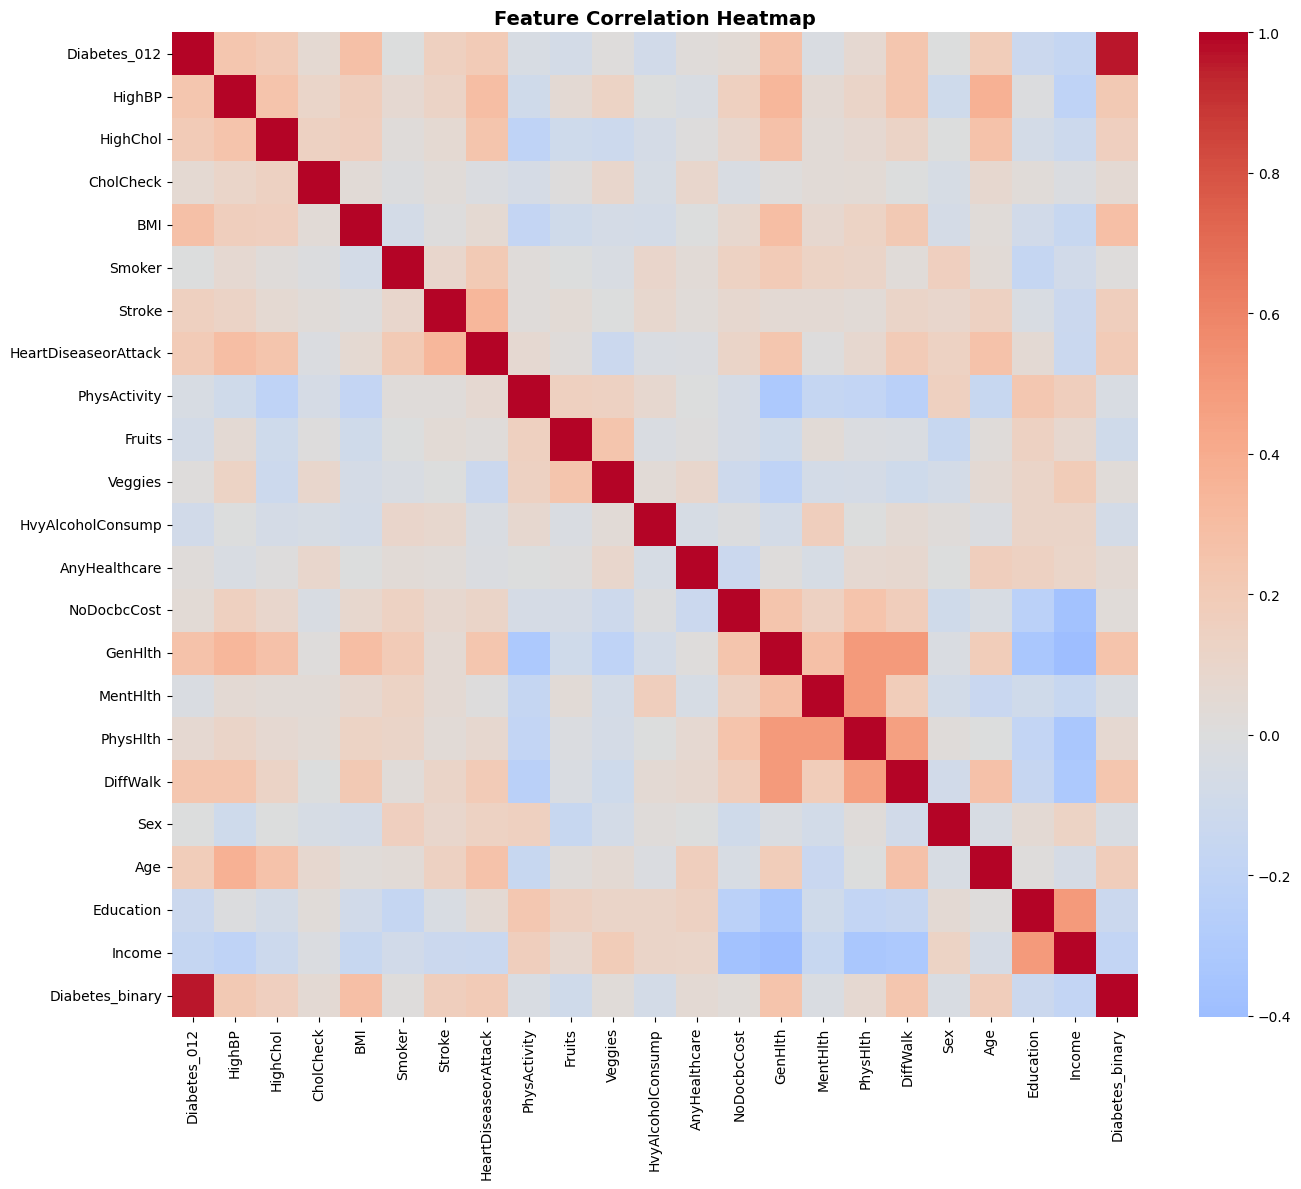

In [34]:
plt.figure(figsize=(14, 12))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### BMI vs diabetes status

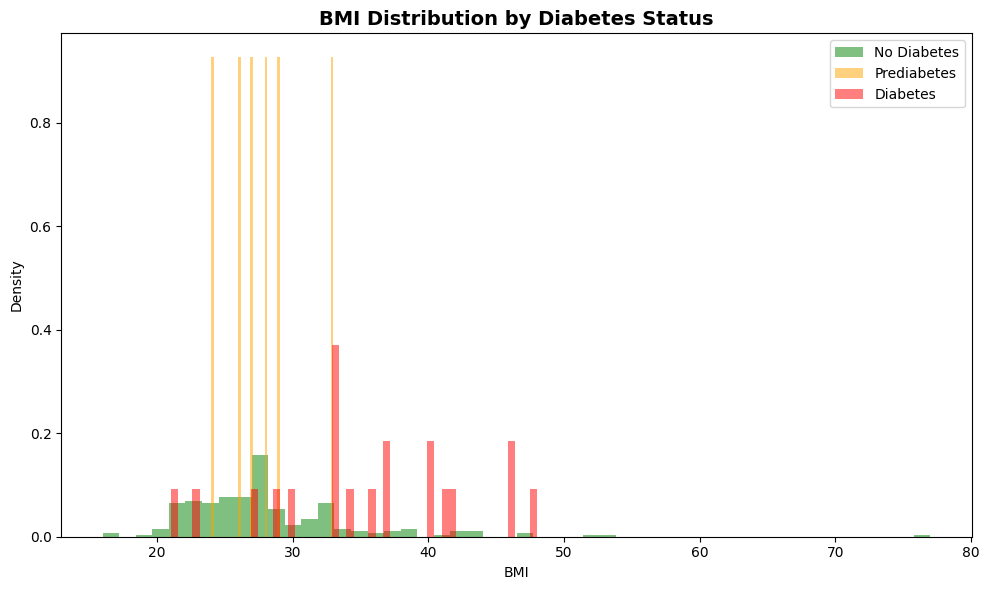

In [35]:
plt.figure(figsize=(10, 6))
for status, color, label in [(0, 'green', 'No Diabetes'), (1, 'orange', 'Prediabetes'), (2, 'red', 'Diabetes')]:
    subset = df[df['Diabetes_012'] == status]
    plt.hist(subset['BMI'], bins=50, alpha=0.5, color=color, label=label, density=True)
plt.title('BMI Distribution by Diabetes Status', fontsize=14, fontweight='bold')
plt.xlabel('BMI')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('eda_bmi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Age distribution

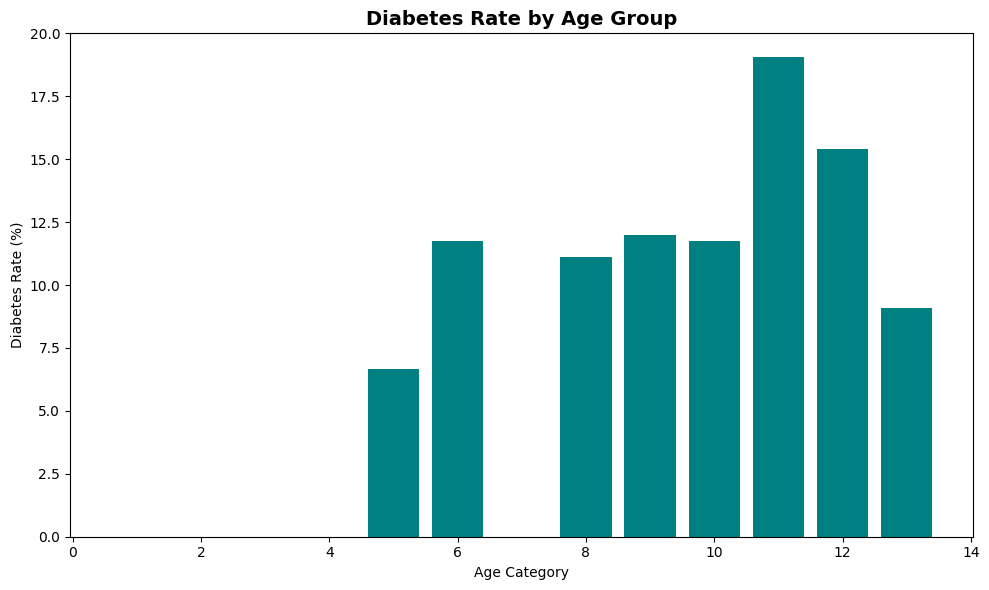

In [36]:
plt.figure(figsize=(10, 6))
age_by_diabetes = df.groupby('Age')['Diabetes_binary'].mean() * 100
plt.bar(age_by_diabetes.index, age_by_diabetes.values, color='teal')
plt.title('Diabetes Rate by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Category')
plt.ylabel('Diabetes Rate (%)')
plt.tight_layout()
plt.savefig('eda_age_diabetes_rate.png', dpi=150, bbox_inches='tight')
plt.show()

# Variable typing

In [37]:
binary_vars = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
               'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
               'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

numerical_vars = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'Income', 'Education', 'GenHlth']

all_vars = binary_vars + numerical_vars + ['Diabetes_012', 'Diabetes_binary']
print(f"\nAll columns accounted for: {set(df.columns) == set(all_vars)}")


All columns accounted for: True


# Normalisation

In [38]:
df_normalized = df.copy()

In [39]:
scaler = StandardScaler()
df_normalized[numerical_vars] = scaler.fit_transform(df[numerical_vars])

print(f"Applied StandardScaler to: {numerical_vars}")
print("\nNormalized statistics (BMI after scaling):")
print(df_normalized['BMI'].describe())

Applied StandardScaler to: ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'Income', 'Education', 'GenHlth']

Normalized statistics (BMI after scaling):
count    2.400000e+02
mean     2.405483e-16
std      1.002090e+00
min     -1.822707e+00
25%     -6.816580e-01
50%     -2.537646e-01
75%      4.593912e-01
max      6.877793e+00
Name: BMI, dtype: float64


# Saving cleaned dataset

In [41]:
df.to_csv(r'C:\Users\Admin\Downloads\Sprint 1\Sprint 1\diabetes_cleaned.csv', index=False)
print("dataset saved")

dataset saved


In [43]:
df_normalized.to_csv(r'C:\Users\Admin\Downloads\Sprint 1\Sprint 1\diabetes_cleaned_normalized.csv', index=False)
print("normalised dataset saved")

normalised dataset saved


# Target vs explanatory variables

In [44]:
X = df.drop(['Diabetes_012', 'Diabetes_binary'], axis=1)
y = df['Diabetes_binary']

print(f"\nFeatures: {X.shape[1]} columns")
print(f"Feature names: {X.columns.tolist()}")


Features: 21 columns
Feature names: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


# Sample data

## Stratified sample

In [46]:
sample_size = 200
X_sample, _, y_sample, _ = train_test_split(
    X, y,
    train_size=sample_size,
    random_state=42,
    stratify=y
)

print(f"\nSampled {sample_size:,} records for training")


Sampled 200 records for training


## Split data

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample,
    test_size=0.2,
    random_state=42,
    stratify=y_sample
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 160 samples
Test set: 40 samples


# Conclusion
The deliverable has been successfully transformed raw CDC BRFSS 2015 survey data into a clean, normalized, and well-understood dataset ready for modeling. All required tasks were completed with respect to the constraints.

The insights gained during exploratory analysis will directly inform modeling decisions in the next phase, ensuring that the final model is both performant and interpretable.